# Greedy vs GA with walking speed.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
folder = 'outputs/runs/'

In [4]:
from utils.comparison_metrics import (
    build_results_table,
    extract_results,
    format_results_table,
    extract_cohens_d,
    calculate_poa,
    build_delta_table,
    plot_dispersion_all_cities,
    plot_metrics_by_human_behaviour
)
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [5]:
from utils.environment import Environment

grid = Environment('grid-like_topology')
moderate = Environment('moderate-complexity_topology')
bottleneck = Environment('bottleneck-constrained_topology')

graphs = {
    'Grid': grid.graph, 'Moderate': moderate.graph, 'Bottleneck': bottleneck.graph
}

positions = {
    'Grid': grid.pos, 'Moderate': moderate.pos, 'Bottleneck': bottleneck.pos
}


In [6]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

# Comparisons

In [7]:
experiment_files = {
    'Grid': {
        0.0:  f'{folder}grid_city_Falsewalking_Falsedelay_0compliance.pkl',
        0.25: f'{folder}grid_city_Falsewalking_Falsedelay_025compliance.pkl',
        0.5:  f'{folder}grid_city_Falsewalking_Falsedelay_05compliance.pkl',
        0.75: f'{folder}grid_city_Falsewalking_Falsedelay_075compliance.pkl',
        1.0:  f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    },
    'Moderate': {
        0.0:  f'{folder}moderate_city_Falsewalking_Falsedelay_0compliance.pkl',
        0.25: f'{folder}moderate_city_Falsewalking_Falsedelay_025compliance.pkl',
        0.5:  f'{folder}moderate_city_Falsewalking_Falsedelay_05compliance.pkl',
        0.75: f'{folder}moderate_city_Falsewalking_Falsedelay_075compliance.pkl',
        1.0:  f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    },
    'Bottleneck': {
        0.0:  f'{folder}bottleneck_city_Falsewalking_Falsedelay_0compliance.pkl',
        0.25: f'{folder}bottleneck_city_Falsewalking_Falsedelay_025compliance.pkl',
        0.5:  f'{folder}bottleneck_city_Falsewalking_Falsedelay_05compliance.pkl',
        0.75: f'{folder}bottleneck_city_Falsewalking_Falsedelay_075compliance.pkl',
        1.0:  f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
    },
}

In [8]:
results = extract_results(experiment_files['Grid'][0.25])
print(f'Params: {results['ga']['params']}')   # {'walking': False, 'delay_start': False, ...}

Params: {'congestion': True, 'walking': False, 'delay_start': False, 'compliance': 0.25, 'fitness': 'max-median', 'alpha': 0.8}


### Comparison begins

In [9]:
def cohens_d(a, b):
    diff = a - b
    return diff.mean() / diff.std()

In [10]:
import numpy as np
from scipy import stats

# PoA for each compliance level
for city in ['Grid', 'Moderate', 'Bottleneck']:
    print(f"\n{city}")
    for comp, path in experiment_files[city].items():
        results = extract_results(path)
        ga_mean = np.mean([e.metrics['Total time'] for e in results['ga']['evals']])
        greedy_mean = np.mean([e.metrics['Total time'] for e in results['greedy']['evals']])
        poa = greedy_mean / ga_mean
        print(f"  compliance={comp}: GA={ga_mean:.2f}, Greedy={greedy_mean:.2f}, PoA={poa:.3f}")


Grid
  compliance=0.0: GA=15.80, Greedy=11.40, PoA=0.722
  compliance=0.25: GA=11.40, Greedy=11.50, PoA=1.009
  compliance=0.5: GA=13.30, Greedy=11.40, PoA=0.857
  compliance=0.75: GA=14.60, Greedy=11.60, PoA=0.795
  compliance=1.0: GA=15.60, Greedy=11.40, PoA=0.731

Moderate
  compliance=0.0: GA=15.30, Greedy=15.50, PoA=1.013
  compliance=0.25: GA=13.40, Greedy=15.50, PoA=1.157
  compliance=0.5: GA=13.50, Greedy=15.50, PoA=1.148
  compliance=0.75: GA=14.40, Greedy=15.50, PoA=1.076
  compliance=1.0: GA=15.30, Greedy=15.50, PoA=1.013

Bottleneck
  compliance=0.0: GA=30.00, Greedy=29.00, PoA=0.967
  compliance=0.25: GA=29.00, Greedy=29.00, PoA=1.000
  compliance=0.5: GA=29.00, Greedy=29.00, PoA=1.000
  compliance=0.75: GA=29.10, Greedy=29.00, PoA=0.997
  compliance=1.0: GA=30.10, Greedy=29.00, PoA=0.963


In [11]:
# Cohen's d and p-value for each compliance level
for city in ['Grid', 'Moderate', 'Bottleneck']:
    print(f"\n{city}")
    for comp, path in experiment_files[city].items():
        results = extract_results(path)
        ga_times = np.array([e.metrics['Total time'] for e in results['ga']['evals']])
        greedy_times = np.array([e.metrics['Total time'] for e in results['greedy']['evals']])
        d = cohens_d(ga_times, greedy_times)
        try:
            _, p = stats.wilcoxon(ga_times, greedy_times)
        except:
            p = 1.0


        print(f"  compliance={comp}: d={d:.2f}, p={p:.3f}")


Grid
  compliance=0.0: d=8.98, p=0.002
  compliance=0.25: d=-0.12, p=1.000
  compliance=0.5: d=2.01, p=0.002
  compliance=0.75: d=2.37, p=0.002
  compliance=1.0: d=4.82, p=0.002

Moderate
  compliance=0.0: d=-0.33, p=0.625
  compliance=0.25: d=-3.90, p=0.002
  compliance=0.5: d=-3.16, p=0.002
  compliance=0.75: d=-1.32, p=0.016
  compliance=1.0: d=-0.23, p=0.727

Bottleneck
  compliance=0.0: d=2.24, p=0.004
  compliance=0.25: d=nan, p=1.000


/var/folders/lz/6hyt90hs5rj1smnclbp276hr0000gn/T/ipykernel_71635/397276088.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return diff.mean() / diff.std()
/Users/laurapowell/Documents/Masters/dissertation/.venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


  compliance=0.5: d=nan, p=1.000
  compliance=0.75: d=0.33, p=1.000
  compliance=1.0: d=3.67, p=0.002


In [12]:
import matplotlib.pyplot as plt

I messed up my compliance 0% runs because I turned off compliance behaviour instead of setting it at zero!!!
So need to use the greedy output as this is what it should have been

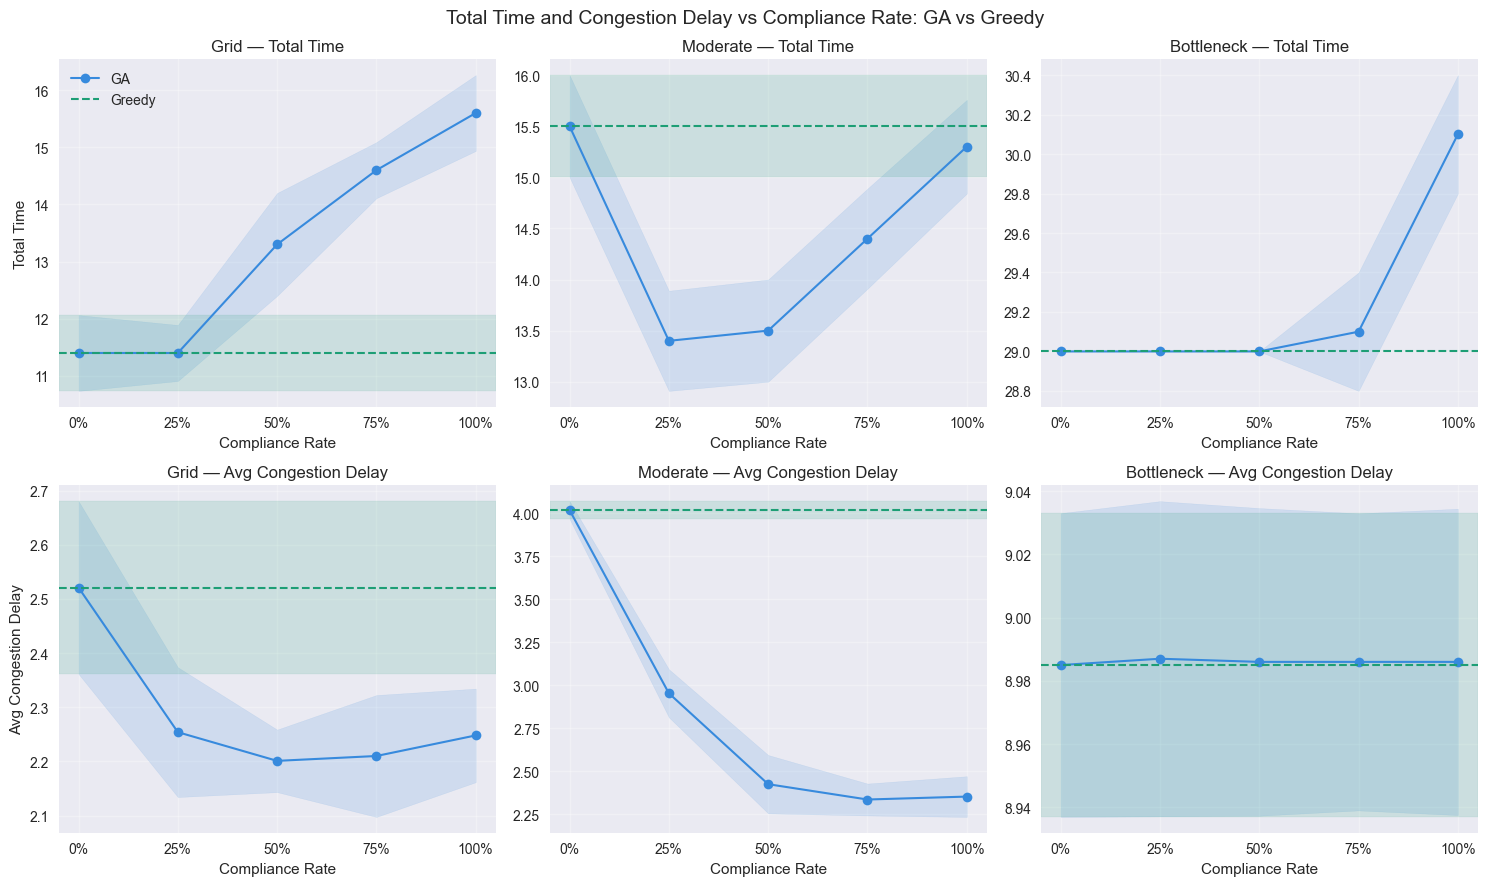

In [13]:
def plot_compliance_metrics(compliance_files: dict, baseline_files: dict) -> None:
    cities = list(compliance_files.keys())
    metrics = ['Total time', 'Avg Congestion delay']
    metric_labels = ['Total Time', 'Avg Congestion Delay']
    ga_colour = "#378ADD"
    greedy_colour = "#1D9E75"

    fig, axes = plt.subplots(2, len(cities), figsize=(5 * len(cities), 9))

    for row, (metric, label) in enumerate(zip(metrics, metric_labels)):
        for col, city in enumerate(cities):
            ax = axes[row, col]
            compliance_levels = sorted([k for k in compliance_files[city].keys() 
                                        if k != 0.0])

            # greedy from 100% compliance file - same human behaviour conditions as GA
            full_compliance_results = extract_results(compliance_files[city][1.0])
            greedy_vals = np.array([e.metrics[metric] 
                                    for e in full_compliance_results['greedy']['evals']])
            greedy_mean = greedy_vals.mean()
            greedy_std = greedy_vals.std()

            # GA values from compliance files
            ga_means, ga_stds = [], []
            for comp in compliance_levels:
                results = extract_results(compliance_files[city][comp])
                ga_vals = np.array([e.metrics[metric] for e in results['ga']['evals']])
                ga_means.append(ga_vals.mean())
                ga_stds.append(ga_vals.std())

            # prepend greedy mean as 0% compliance point
            all_levels = [0.0] + compliance_levels
            ga_means = np.array([greedy_mean] + ga_means)
            ga_stds = np.array([greedy_std] + ga_stds)

            ax.plot(all_levels, ga_means, color=ga_colour, linewidth=1.5,
                    marker='o', label='GA')
            ax.fill_between(all_levels, ga_means - ga_stds, ga_means + ga_stds,
                            alpha=0.15, color=ga_colour)

            ax.axhline(y=greedy_mean, color=greedy_colour, linewidth=1.5,
                       linestyle='--', label='Greedy')
            ax.axhspan(greedy_mean - greedy_std, greedy_mean + greedy_std,
                       alpha=0.15, color=greedy_colour)

            ax.set_title(f"{city} — {label}")
            ax.set_xlabel("Compliance Rate")
            ax.set_ylabel(label if col == 0 else "")
            ax.set_xticks(all_levels)
            ax.set_xticklabels([f"{int(c*100)}%" for c in all_levels])
            ax.grid(True, alpha=0.3)

            if row == 0 and col == 0:
                ax.legend()

    plt.suptitle("Total Time and Congestion Delay vs Compliance Rate: GA vs Greedy", fontsize=14)
    plt.tight_layout()
    plt.show()
    
plot_compliance_metrics(experiment_files, baseline_files)

In [16]:
def build_compliance_stats_table(compliance_files: dict, baseline_files: dict) -> pd.DataFrame:
    rows = []
    
    for city in compliance_files.keys():
        baseline_results = extract_results(baseline_files[city])
        greedy_times = np.array([e.metrics['Total time'] 
                                 for e in baseline_results['greedy']['evals']])
        greedy_mean = greedy_times.mean()
        
        for comp, path in sorted(compliance_files[city].items()):
            if comp == 0.0:
                continue
                
            results = extract_results(path)
            ga_times = np.array([e.metrics['Total time'] 
                                 for e in results['ga']['evals']])
            
            poa = greedy_mean / ga_times.mean()
            
            try:
                _, p = stats.wilcoxon(ga_times, greedy_times)
            except ValueError:
                p = 1.0
                
            try:
                d = cohens_d(ga_times, greedy_times)
            except:
                d = float('nan')
            
            rows.append({
                'Topology':        city,
                'Compliance':      f"{int(comp*100)}%",
                'GA Mean':         round(ga_times.mean(), 2),
                'Greedy Mean':     round(greedy_mean, 2),
                'Delta':           round(ga_times.mean() - greedy_mean, 2),
                'PoA':             round(poa, 3),
                'p-value':         f"{p:.3f}{'*' if p < 0.05 else ''}",
                "Cohen's d":       round(d, 2) if not np.isnan(d) else 'N/A',
            })
    
    df = pd.DataFrame(rows)
    return df.pivot(index=['Topology', 'Compliance'], 
                    columns=[], 
                    values=['GA Mean', 'Greedy Mean', 'Delta', 'PoA', 'p-value', "Cohen's d"])

compliance_stats = build_compliance_stats_table(experiment_files, baseline_files)
compliance_stats.to_clipboard()
compliance_stats

/Users/laurapowell/Documents/Masters/dissertation/.venv/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/var/folders/lz/6hyt90hs5rj1smnclbp276hr0000gn/T/ipykernel_71635/397276088.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return diff.mean() / diff.std()


GA Mean Greedy Mean Delta    PoA p-value Cohen's d
Topology   Compliance                                                   
Grid       25%           11.4        11.4   0.0    1.0   1.000       0.0
           50%           13.3        11.4   1.9  0.857  0.002*      2.01
           75%           14.6        11.4   3.2  0.781  0.002*      3.67
           100%          15.6        11.4   4.2  0.731  0.002*      4.82
Moderate   25%           13.4        15.5  -2.1  1.157  0.002*      -3.9
           50%           13.5        15.5  -2.0  1.148  0.002*     -3.16
           75%           14.4        15.5  -1.1  1.076  0.016*     -1.32
           100%          15.3        15.5  -0.2  1.013   0.727     -0.23
Bottleneck 25%           29.0        29.0   0.0    1.0   1.000       N/A
           50%           29.0        29.0   0.0    1.0   1.000       N/A
           75%           29.1        29.0   0.1  0.997   1.000      0.33
           100%          30.1        29.0   1.1  0.963  0.002*      3.67